# EEdit — Full Evaluation Notebook

Runs **all three tasks** (prompt-guided inpaint, composition, drag) and computes the metrics reported in the EEdit paper (MSE, PSNR, SSIM, LPIPS, CLIP Score).

Input data is downloaded automatically from **your Google Drive input folder**.
Results are uploaded automatically to **your Google Drive output folder**.

After the install cell, **restart the runtime once**, then run all cells in order.

In [1]:
!nvidia-smi || true

!git clone https://github.com/yuriYanZeXuan/EEdit.git /content/EEdit || true
%cd /content/EEdit
!git fetch --all
!git checkout 35e95e3

%pip uninstall -y numpy opencv-python opencv-python-headless || true
%pip install -q --upgrade pip
%pip install -q --upgrade --force-reinstall --no-cache-dir \
  numpy==1.26.4 \
  torch==2.5.1 torchvision==0.20.1 xformers==0.0.28.post3 \
  diffusers==0.31.0 transformers==4.46.1 accelerate==1.1.0 \
  sentencepiece==0.2.0 safetensors==0.5.2 huggingface_hub==0.26.2 \
  ftfy==6.3.1 einops==0.8.1 omegaconf==2.3.0 \
  pillow==11.1.0 opencv-python-headless==4.10.0.84 gdown \
  lpips torchmetrics

print('Install complete. Restart the runtime now, then continue.')

Wed May 27 18:53:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import numpy, torch, transformers
print('numpy:', numpy.__version__)
print('torch:', torch.__version__)
print('transformers:', transformers.__version__)
assert numpy.__version__ == '1.26.4', 'Wrong numpy â€” rerun install and restart runtime'
assert torch.cuda.is_available(), 'No CUDA GPU â€” switch to GPU runtime'
major, minor = torch.cuda.get_device_capability()
DEVICE = 'cuda'
DTYPE = torch.bfloat16 if major >= 8 else torch.float16
print('GPU:', torch.cuda.get_device_name(0))
print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')
print('dtype:', DTYPE)

numpy: 1.26.4
torch: 2.5.1+cu124
transformers: 4.46.1
GPU: NVIDIA A100-SXM4-80GB
VRAM: 79.3 GB
dtype: torch.bfloat16


In [2]:
# Patch gen scripts: use weights/transformer/ dir for config (regex match — robust to quote style).
%cd /content/EEdit
import re

HELPER = """
def _resolve_transformer_config(weights_dir):
    import os, shutil
    dir_path = os.path.join(weights_dir, "transformer")
    if os.path.isfile(os.path.join(dir_path, "config.json")):
        return dir_path
    fallback_dir = os.path.join(weights_dir, "transformer_config_dir")
    os.makedirs(fallback_dir, exist_ok=True)
    dst = os.path.join(fallback_dir, "config.json")
    if not os.path.exists(dst):
        shutil.copy2(os.path.join(weights_dir, "transformer_config.json"), dst)
    return fallback_dir

"""

for script in ["composition_gen.py", "inpaint_gen.py", "drag_gen.py"]:
    path = f"/content/EEdit/{script}"
    text = open(path).read()
    if "_resolve_transformer_config" in text:
        print(f"{script}: already patched"); continue
    new_text = re.sub(
        r"config\s*=\s*[^\n,]*transformer_config\.json[^\n,]*",
        "config=_resolve_transformer_config(args.weights_dir)",
        text
    )
    new_text = new_text.replace("def load_models(", HELPER + "def load_models(", 1)
    open(path, "w").write(new_text)
    print(f"Patched {script}")

/content/EEdit
Patched composition_gen.py
Patched inpaint_gen.py
Patched drag_gen.py


In [3]:
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload
from datetime import datetime
from pathlib import Path
import os

auth.authenticate_user()
drive_service = build("drive", "v3")

INPUT_FOLDER_ID  = "1j6ynVHSW3PGM14yU30Pq3aMxqlU9t6cu"
OUTPUT_FOLDER_ID = "1R0DNBTzobpIOyYDZuy5YZ2lc599nTu8Q"

# Create one timestamped run folder — all task results go inside it
_ts = datetime.now().strftime("%Y%m%d_%H%M")
RUN_FOLDER_ID = None  # created lazily on first upload

def _get_run_folder():
    global RUN_FOLDER_ID
    if RUN_FOLDER_ID is None:
        RUN_FOLDER_ID = _gdrive_mkdir(drive_service, f"EEdit_run_{_ts}", OUTPUT_FOLDER_ID)
        print(f"Created run folder: EEdit_run_{_ts}")
        print(f"View: https://drive.google.com/drive/folders/{OUTPUT_FOLDER_ID}")
    return RUN_FOLDER_ID

def _gdrive_mkdir(service, name, parent_id):
    meta = {"name": name,
            "mimeType": "application/vnd.google-apps.folder",
            "parents": [parent_id]}
    return service.files().create(body=meta, fields="id").execute()["id"]

def _gdrive_upload_file(service, local_path, parent_id):
    meta = {"name": os.path.basename(local_path), "parents": [parent_id]}
    media = MediaFileUpload(local_path, resumable=True)
    service.files().create(body=meta, media_body=media, fields="id").execute()

def _upload_tree(service, local_dir, parent_id):
    total = 0
    for item in sorted(Path(local_dir).iterdir()):
        if item.is_dir():
            child_id = _gdrive_mkdir(service, item.name, parent_id)
            total += _upload_tree(service, str(item), child_id)
        else:
            _gdrive_upload_file(service, str(item), parent_id)
            total += 1
    return total

def upload_task_results(task_name, generated_dir, originals_dir=None):
    """Upload generated + originals to Drive/EEdit_run_<ts>/<task_name>/"""
    task_id = _gdrive_mkdir(drive_service, task_name, _get_run_folder())
    total = 0
    if os.path.isdir(generated_dir):
        gen_id = _gdrive_mkdir(drive_service, "generated", task_id)
        n = _upload_tree(drive_service, generated_dir, gen_id)
        print(f"  generated/: {n} files")
        total += n
    if originals_dir and os.path.isdir(originals_dir):
        orig_id = _gdrive_mkdir(drive_service, "originals", task_id)
        n = _upload_tree(drive_service, originals_dir, orig_id)
        print(f"  originals/: {n} files")
        total += n
    print(f"[{task_name}] uploaded {total} files total.")
    return task_id

print("Google Drive authenticated. Upload helpers ready.")
print(f"Output folder: https://drive.google.com/drive/folders/1R0DNBTzobpIOyYDZuy5YZ2lc599nTu8Q")


Google Drive authenticated. Upload helpers ready.
Output folder: https://drive.google.com/drive/folders/1R0DNBTzobpIOyYDZuy5YZ2lc599nTu8Q


In [5]:
import os, shutil, zipfile
from pathlib import Path
from googleapiclient.http import MediaIoBaseDownload

INPAINT_DIR     = "/content/EEdit/input/inpaint"
COMPOSITION_DIR = "/content/TF-ICON/inputs"
DRAG_DIR        = "/content/EEdit/input/drag_data"
for d in [INPAINT_DIR, COMPOSITION_DIR, DRAG_DIR]:
    os.makedirs(d, exist_ok=True)

def gdrive_download(service, file_id, dest_path):
    req = service.files().get_media(fileId=file_id)
    with open(dest_path, "wb") as fh:
        dl = MediaIoBaseDownload(fh, req, chunksize=64*1024*1024)
        done = False
        while not done:
            status, done = dl.next_chunk()
            print(f"  {status.progress()*100:.0f}%", end="\r")
    print(f"  Downloaded: {os.path.basename(dest_path)}")

def extract_zip(zip_path, dest_dir):
    tmp = zip_path + "_tmp"
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(tmp)
    items = [x for x in os.listdir(tmp) if x != "__MACOSX"]
    src = (os.path.join(tmp, items[0])
           if len(items) == 1 and os.path.isdir(os.path.join(tmp, items[0]))
           else tmp)
    for item in os.listdir(src):
        dst = os.path.join(dest_dir, item)
        if os.path.exists(dst):
            shutil.rmtree(dst) if os.path.isdir(dst) else os.remove(dst)
        shutil.move(os.path.join(src, item), dst)
    shutil.rmtree(tmp, ignore_errors=True)

def detect_dest(zip_path, fname):
    with zipfile.ZipFile(zip_path, "r") as z:
        joined = " ".join(z.namelist()).lower()
    if "annotation_images" in joined or "mapping_file.json" in joined:
        return INPAINT_DIR, "Inpaint (PIE-Bench)"
    if "same_domain" in joined or "cross_domain" in joined:
        return COMPOSITION_DIR, "Composition (TF-ICON)"
    if "original_image.png" in joined or "meta_data.pkl" in joined:
        return DRAG_DIR, "Drag (DragBench)"
    n = fname.lower()
    if any(k in n for k in ["pie", "inpaint", "annotation"]):
        return INPAINT_DIR, "Inpaint [name-match]"
    if any(k in n for k in ["tficon", "tf-icon", "composition", "same_domain"]):
        return COMPOSITION_DIR, "Composition [name-match]"
    if any(k in n for k in ["drag", "dragbench"]):
        return DRAG_DIR, "Drag [name-match]"
    return None, "Unknown — skipped"

results = drive_service.files().list(
    q="'1j6ynVHSW3PGM14yU30Pq3aMxqlU9t6cu' in parents and trashed=false",
    fields="files(id, name, mimeType, size)"
).execute()
files = results.get("files", [])
print(f"Found {len(files)} file(s) in input Drive folder:")
for fi in files:
    mb = int(fi.get("size", 0)) / 1024**2
    print(f'  {fi["name"]}  ({mb:.1f} MB)')

print()
for fi in files:
    # Skip downloading if the item is a Google Drive folder
    if fi["mimeType"] == "application/vnd.google-apps.folder":
        print(f"Skipping folder: {fi['name']}")
        continue

    local_path = f'/content/{fi["name"]}'
    print(f'Downloading {fi["name"]} ...')
    gdrive_download(drive_service, fi["id"], local_path)
    if fi["name"].endswith(".zip"):
        dest, label = detect_dest(local_path, fi["name"])
        if dest:
            print(f'  Extracting as {label} -> {dest}')
            extract_zip(local_path, dest)
        else:
            print(f'  {label}')
        os.remove(local_path)
    elif fi["name"] == "mapping_file.json":
        shutil.copy(local_path, os.path.join(INPAINT_DIR, fi["name"]))

print()
print("=== Input data summary ===")
for label, d in [("Inpaint", INPAINT_DIR),
                  ("Composition", COMPOSITION_DIR),
                  ("Drag", DRAG_DIR)]:
    n = sum(1 for _ in Path(d).rglob("*") if _.is_file()) if os.path.isdir(d) else 0
    status = "OK" if n > 0 else "EMPTY — check your Drive folder"
    print(f'  {label}: {n} files  [{status}]')


Found 6 file(s) in input Drive folder:
  composition  (0.0 MB)
  drag_data  (0.0 MB)
  inpaint  (0.0 MB)
  drag_data.zip  (314.4 MB)
  composition.zip  (164.7 MB)
  inpaint.zip  (73.2 MB)

Skipping folder: composition
Skipping folder: drag_data
Skipping folder: inpaint
  Downloaded: drag_data.zip
  Extracting as Drag (DragBench) -> /content/EEdit/input/drag_data
  Downloaded: composition.zip
  Extracting as Composition [name-match] -> /content/TF-ICON/inputs
  Downloaded: inpaint.zip
  Extracting as Inpaint (PIE-Bench) -> /content/EEdit/input/inpaint

=== Input data summary ===
  Inpaint: 1461 files  [OK]
  Composition: 1990 files  [OK]
  Drag: 1525 files  [OK]


In [7]:
import os
print('Contents of /content/TF-ICON/inputs:')
for item in os.listdir('/content/TF-ICON/inputs'):
    print(f'- {item}')

Contents of /content/TF-ICON/inputs:
- Real-Sketch
- Real-Cartoon
- Real-Real
- Real-Painting


## 1. Hugging Face Weights

Accept the FLUX.1-dev access agreement first: https://huggingface.co/black-forest-labs/FLUX.1-dev

In [6]:
from huggingface_hub import login, snapshot_download
from getpass import getpass
import os

token = getpass('Hugging Face token: ')
login(token=token)

os.makedirs('/content/EEdit/weights', exist_ok=True)

snapshot_download(
    repo_id='black-forest-labs/FLUX.1-dev',
    local_dir='/content/EEdit/weights',
    allow_patterns=[
        'flux1-dev.safetensors',
        'transformer/config.json',
        'transformer_config.json',
        'model_index.json',
        'scheduler/*',
        'text_encoder/*',
        'text_encoder_2/*',
        'tokenizer/*',
        'tokenizer_2/*',
        'vae/*',
    ],
)
print('Weights downloaded.')

Hugging Face token: ··········


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.53G [00:00<?, ?B/s]

flux1-dev.safetensors:   0%|          | 0.00/23.8G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/820 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

Weights downloaded.


In [8]:
%cd /content/EEdit
import json, os
from pathlib import Path

# Generate mask PNGs from mapping_file.json
!python MyCodes/myutils.py

# Build full prompt_images.json â€” one entry per mapping_file.json row
mapping_path = '/content/EEdit/input/inpaint/mapping_file.json'
annotation_root = Path('/content/EEdit/input/inpaint/annotation_images')
mask_dir = Path('/content/EEdit/input/inpaint/masks')

with open(mapping_path) as f:
    mapping = json.load(f)

imgs, missing = [], 0
for idx, (key, item) in enumerate(mapping.items()):
    prompt = item['editing_prompt'].replace('[', '').replace(']', '')
    mask_abs = mask_dir / f'mask-{idx:03d}.png'
    if not mask_abs.exists():
        missing += 1; continue

    # Locate image by COCO key (try zero-padded 12-digit filename)
    found = None
    for key_try in (str(key).zfill(12), str(key)):
        for ext in ('.jpg', '.jpeg', '.png'):
            for match in annotation_root.rglob(f'{key_try}{ext}'):
                found = './' + str(match.relative_to('/content/EEdit')).replace('\\', '/')
                break
            if found: break
        if found: break

    if found:
        imgs.append({'prompt': prompt, 'image': found,
                     'mask_image': f'./input/inpaint/masks/mask-{idx:03d}.png',
                     'height': 512, 'width': 512})
    else:
        missing += 1

out_path = '/content/EEdit/configs/prompt-guided/prompt_images.json'
with open(out_path, 'w') as f:
    json.dump({'imgs': imgs}, f, indent=2)

print(f'Built {out_path}')
print(f'  Entries: {len(imgs)}  |  Missing images/masks: {missing}')

/content/EEdit
Built /content/EEdit/configs/prompt-guided/prompt_images.json
  Entries: 700  |  Missing images/masks: 0


### Smoke Test — Inpaint (2 images)

Runs inpaint on **2 images** to verify the pipeline works before committing to the full ~700-image run.
If this fails, fix the error before running the full pipeline.

In [14]:
%cd /content/EEdit
import json, os, re
from pathlib import Path

# --- Start Patch for inpaint_gen.py ---
path_to_inpaint_gen = "./inpaint_gen.py"
with open(path_to_inpaint_gen, "r") as f:
    content = f.read()

# Safely replace the edit_mask_parser call, no matter what height/width variables were tried before
content = re.sub(
    r"edit_idx=edit_mask_parser\(mask_image,cascade_num=param\['cascade_num'\](.*)\)",
    "edit_idx=edit_mask_parser(mask_image,cascade_num=param['cascade_num'], height=512, width=512)",
    content
)

# Safely replace the convert_to_cache_index call
content = re.sub(
    r"convert_to_cache_index\(edit_idx,edit_base=param\.get\('edit_base',2\),bonus_ratio=param\.get\('bonus_ratio',0\.8\)(.*)\)",
    "convert_to_cache_index(edit_idx,edit_base=param.get('edit_base',2),bonus_ratio=param.get('bonus_ratio',0.8), height=512, width=512)",
    content
)

with open(path_to_inpaint_gen, "w") as f:
    f.write(content)
print("inpaint_gen.py patched successfully.")
# --- End Patch for inpaint_gen.py ---

with open("configs/prompt-guided/prompt_images.json") as f:
    full = json.load(f)
assert len(full["imgs"]) > 0, "prompt_images.json is empty — run the masks-and-imgconfig cell first"

test_cfg = {"imgs": full["imgs"][:2]}
with open("configs/prompt-guided/test_prompt_images.json", "w") as f:
    json.dump(test_cfg, f)
print(f'Smoke-test config: {len(test_cfg["imgs"])} images')

os.makedirs("EEdit_outputs/test_inpaint", exist_ok=True)
!python inpaint_gen.py \
  --weights_dir ./weights \
  --config_path ./configs/prompt-guided/cache_configs.json \
  --img_config  ./configs/prompt-guided/test_prompt_images.json \
  --output_dir  ./EEdit_outputs/test_inpaint \
  --use_predefine 1

n = len(list(Path("EEdit_outputs/test_inpaint").glob("*.png")))
print(f"\nSmoke-test result: {n}/2 images generated.")
if n == 0:
    raise RuntimeError("Inpaint smoke test FAILED — 0 images produced. Fix the error above before running the full pipeline.")
elif n < 2:
    print(f"WARNING: only {n}/2 images produced — check for errors above.")
else:
    print("Smoke test PASSED. Ready for full inpaint run.")

/content/EEdit
inpaint_gen.py patched successfully.
Smoke-test config: 2 images
2026-05-27 19:11:08.857462: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-27 19:11:08.923411: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.78it/s]
Loading pipeline components...:  20% 1/5 [00:00<00:00,  9.70it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:0

## 3. Run Prompt-Guided Editing (Full PIE-Bench)

Runs `inpaint_gen.py` on all PIE-Bench images. ~700 images Ã— 28 steps â‰ˆ 45â€“60 min on A100.

In [15]:
%cd /content/EEdit
import gc, torch
gc.collect(); torch.cuda.empty_cache()

os.makedirs('EEdit_outputs/inpaint', exist_ok=True)

!python inpaint_gen.py \
  --weights_dir ./weights \
  --config_path ./configs/prompt-guided/cache_configs.json \
  --img_config  ./configs/prompt-guided/prompt_images.json \
  --output_dir  ./EEdit_outputs/inpaint \
  --use_predefine 1

n = len(list(Path('EEdit_outputs/inpaint').glob('*.png')))
print(f'\nInpaint done: {n} images saved.')

/content/EEdit
2026-05-27 19:11:59.513142: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-27 19:11:59.578294: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.82it/s]
Loading pipeline components...:  60% 3/5 [00:00<00:00,  6.98it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:00<00:00,  6.16it/s]
100% 28/28 [00:02<00:00, 11.92it/s]
100% 28/2

In [15]:
%cd /content/EEdit
from pathlib import Path

gen_dir = Path("EEdit_outputs/inpaint")
gen_files = list(gen_dir.glob("*.png"))

print(f"Inpaint: {len(gen_files)} generated images")
print("Uploading ONLY generated images to Drive...")
upload_task_results("inpaint", str(gen_dir))

/content/EEdit
Inpaint: 700 generated, 700 originals
Uploading to Drive...


Created run folder: EEdit_run_20260527_1856
View: https://drive.google.com/drive/folders/1R0DNBTzobpIOyYDZuy5YZ2lc599nTu8Q
  generated/: 700 files


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_8424/311731484.py", line 23, in <cell line: 0>
    upload_task_results("inpaint", str(gen_dir), str(orig_dir))
  File "/tmp/ipykernel_8424/2225246271.py", line 59, in upload_task_results
    n = _upload_tree(drive_service, originals_dir, orig_id)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_8424/2225246271.py", line 44, in _upload_tree
    _gdrive_upload_file(service, str(item), parent_id)
  File "/tmp/ipykernel_8424/2225246271.py", line 35, in _gdrive_upload_file
    service.files().create(body=meta, media_body=media, fields="id").execute()
  File "/usr/local/lib/python3.12/dist-packages/googleapiclient/_helpers.py", line 130, in positional_wrapper
    return wrapped(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/l


KeyboardInterrupt



## 4. Composition (Full TF-ICON — same_domain + cross_domain)

TF-ICON benchmark data was extracted from your Drive ZIP to `/content/TF-ICON/inputs/`.
This cell organises it into per-group image configs and runs composition.

In [19]:
import os, re, json, shutil, numpy as np
from pathlib import Path
from PIL import Image

tf_root = Path('/content/TF-ICON/inputs')
eedit_root = Path('/content/EEdit/input/composition')
cfg_root = Path('/content/EEdit/configs/composition')
eedit_root.mkdir(parents=True, exist_ok=True)

groups = {'Real-Cartoon': [], 'Real-Painting': [], 'Real-Sketch': [], 'Real-Real': []}

def pick(files, patterns, exclude=()):
    for pat in patterns:
        for f in files:
            if re.match(pat, f.name.lower()) and not any(e in f.name.lower() for e in exclude):
                return f
    return None

# Updated to search within Real-* directories directly, matching your zip structure
for group_name in ['Real-Cartoon', 'Real-Painting', 'Real-Sketch', 'Real-Real']:
    domain_path = tf_root / group_name
    if not domain_path.exists(): continue
    for idx, sample_dir in enumerate(sorted(domain_path.iterdir())):
        if not sample_dir.is_dir(): continue
        prompt = sample_dir.name
        group = group_name
        files = [p for p in sample_dir.iterdir() if p.is_file()]
        bg = pick(files, [r'^bg.*\.(jpg|jpeg|png)$'])
        ref_img = pick(files, [r'^fg.*\.(jpg|jpeg|png)$', r'^dccf.*\.jpg$'], exclude=('_mask',))
        ref_mask = pick(files, [r'^fg.*_mask.*\.(png|jpg)$'])
        place_mask = pick(files, [r'^mask_bg_fg.*\.(jpg|png)$'])
        if not all([bg, ref_img, place_mask]): continue

        slug = f'{group_name[:2]}_{idx:04d} {prompt[:60]}'
        out_dir = eedit_root / group / slug
        out_dir.mkdir(parents=True, exist_ok=True)
        for src in [bg, ref_img, place_mask] + ([ref_mask] if ref_mask else []):
            if src: shutil.copy2(src, out_dir / src.name)

        arr = np.array(Image.open(place_mask).convert('L'))
        ys, xs = np.where(arr > 10)
        if len(xs) == 0: continue
        x1, x2 = int(xs.min()), int(xs.max())
        y1, y2 = int(ys.min()), int(ys.max())

        entry = {'prompt': prompt,
                 'main_image':    str(out_dir / bg.name).replace('/content/EEdit/', './'),
                 'ref_image':     str(out_dir / ref_img.name).replace('/content/EEdit/', './'),
                 'ref_segment':   str(out_dir / (ref_mask.name if ref_mask else ref_img.name)).replace('/content/EEdit/', './'),
                 'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2}
        groups[group].append(entry)

for group, imgs in groups.items():
    out_json = cfg_root / f'{group}.json'
    with open(out_json, 'w') as f:
        json.dump({'imgs': imgs}, f, indent=2)
    print(f'{group}: {len(imgs)} samples -> {out_json}')

Real-Cartoon: 27 samples -> /content/EEdit/configs/composition/Real-Cartoon.json
Real-Painting: 37 samples -> /content/EEdit/configs/composition/Real-Painting.json
Real-Sketch: 31 samples -> /content/EEdit/configs/composition/Real-Sketch.json
Real-Real: 237 samples -> /content/EEdit/configs/composition/Real-Real.json


### Smoke Test — Composition (1 image per group)

Runs composition on **1 image per domain group** before the full run.
Skips groups that have no data.

In [20]:
%cd /content/EEdit
import json, os
from pathlib import Path

GROUP_CFGS = [
    ("Real-Cartoon",  "RC_config.json"),
    ("Real-Painting", "RP_config.json"),
    ("Real-Sketch",   "RS_config.json"),
    ("Real-Real",     "RR_config.json"),
]

test_results = {}
for group, cfg_file in GROUP_CFGS:
    img_cfg = f"configs/composition/{group}.json"
    if not os.path.exists(img_cfg):
        print(f"Skipping {group} — no config"); continue
    with open(img_cfg) as f:
        full = json.load(f)
    if len(full["imgs"]) == 0:
        print(f"Skipping {group} — 0 images"); continue

    test_cfg = {"imgs": full["imgs"][:1]}
    test_cfg_path = f"configs/composition/test_{group}.json"
    with open(test_cfg_path, "w") as f:
        json.dump(test_cfg, f)

    out_dir = f"EEdit_outputs/test_comp/{group}"
    os.makedirs(out_dir, exist_ok=True)
    print(f"\n--- Smoke test: {group} ---")
    !python composition_gen.py \
      --weights_dir ./weights \
      --config_path ./configs/composition/{cfg_file} \
      --img_config  ./configs/composition/test_{group}.json \
      --output_dir  ./EEdit_outputs/test_comp/{group} \
      --use_predefine 1

    n = len(list(Path(out_dir).glob("*.png")))
    test_results[group] = n
    print(f"  {group}: {n}/1 image generated.")

print("\n=== Composition smoke-test summary ===")
all_ok = True
for group, n in test_results.items():
    status = "PASSED" if n > 0 else "FAILED"
    print(f"  {group}: {status} ({n}/1)")
    if n == 0: all_ok = False
if not all_ok:
    raise RuntimeError("One or more composition smoke tests FAILED. Fix errors above before running the full pipeline.")
print("All composition smoke tests PASSED.")


/content/EEdit

--- Smoke test: Real-Cartoon ---
2026-05-27 21:06:40.686076: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-27 21:06:40.751470: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.60it/s]
Loading pipeline components...:  40% 2/5 [00:00<00:00, 19.83it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:00<00:00,  6.25it/s]
100% 28/28 

In [21]:
%cd /content/EEdit
import gc, torch, json, os
gc.collect(); torch.cuda.empty_cache()

GROUP_CFGS = [
    ('Real-Cartoon',  'RC_config.json'),
    ('Real-Painting', 'RP_config.json'),
    ('Real-Sketch',   'RS_config.json'),
    ('Real-Real',     'RR_config.json'),
]

for group, cfg_file in GROUP_CFGS:
    img_cfg = f'/content/EEdit/configs/composition/{group}.json'
    if not os.path.exists(img_cfg):
        print(f'Skipping {group} â€” no config'); continue
    with open(img_cfg) as f:
        n = len(json.load(f)['imgs'])
    if n == 0:
        print(f'Skipping {group} â€” 0 images'); continue

    print(f'\n=== {group} ({n} images) ===')
    os.makedirs(f'EEdit_outputs/comp/{group}', exist_ok=True)
    !python composition_gen.py \
      --weights_dir ./weights \
      --config_path ./configs/composition/{cfg_file} \
      --img_config  ./configs/composition/{group}.json \
      --output_dir  ./EEdit_outputs/comp/{group} \
      --use_predefine 1

print('\nComposition done.')

/content/EEdit

=== Real-Cartoon (27 images) ===
2026-05-27 21:09:16.488071: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-27 21:09:16.553211: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.79it/s]
Loading pipeline components...:  80% 4/5 [00:00<00:00,  8.05it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:00<00:00,  6.10it/s]
100% 28/28 

In [23]:
%cd /content/EEdit
from pathlib import Path

print("Uploading ONLY generated composition results to Drive...")
upload_task_results("composition", "EEdit_outputs/comp")

/content/EEdit
Uploading ONLY generated composition results to Drive...
  generated/: 332 files
[composition] uploaded 332 files total.


'1qi-QN-TTBPt0BkkEwcY7KK5ACsyrCzof'

### Composition Metrics (background preservation + CLIP)

Uses `mask_bg_fg.jpg` (or bounding box fallback) to isolate the background, then computes MSE / PSNR / SSIM / LPIPS on the unedited region and CLIP text-image score.

In [24]:
%cd /content/EEdit
import os, json, sys
import numpy as np
import torch
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
from tqdm import tqdm
from torchmetrics.multimodal.clip_score import CLIPScore

sys.path.insert(0, "/content/EEdit/img_metrics")
from calculate_ssim import calculate_ssim
from calculate_psnr import calculate_psnr
from calculate_lpips import calculate_lpips
from calculate_mse  import calculate_mse

SIZE = 512
clip_metric = CLIPScore(model_name_or_path="openai/clip-vit-large-patch14").to("cuda").eval()

def load_t(path):
    return T.ToTensor()(Image.open(path).convert("RGB").resize((SIZE, SIZE)))

comp_results = {}
for group in ["Real-Cartoon", "Real-Painting", "Real-Sketch", "Real-Real"]:
    cfg_path = f"configs/composition/{group}.json"
    out_dir  = Path(f"EEdit_outputs/comp/{group}")
    if not os.path.exists(cfg_path) or not out_dir.exists():
        continue
    with open(cfg_path) as f:
        cfg = json.load(f)
    group_results = []
    for i, gf in enumerate(tqdm(sorted(out_dir.glob("*.png")), desc=group)):
        if i >= len(cfg["imgs"]): break
        item     = cfg["imgs"][i]
        main_abs = item["main_image"].lstrip("./")
        if not os.path.exists(main_abs): continue

        orig   = load_t(main_abs)
        edited = load_t(str(gf))

        # Prefer place-mask file; fall back to bounding box
        main_dir     = Path(main_abs).parent
        place_masks  = list(main_dir.glob("mask_bg_fg.*"))
        if place_masks:
            mp        = Image.open(str(place_masks[0])).convert("L").resize((SIZE, SIZE))
            comp_mask = T.ToTensor()(mp).float()
        else:
            orig_pil  = Image.open(main_abs)
            sx, sy    = SIZE / orig_pil.width, SIZE / orig_pil.height
            comp_mask = torch.zeros(1, SIZE, SIZE)
            comp_mask[:, int(item["y1"]*sy):int(item["y2"]*sy),
                          int(item["x1"]*sx):int(item["x2"]*sx)] = 1.0

        bg_mask = (comp_mask < 0.5).float()
        orig_bg, edit_bg = orig * bg_mask, edited * bg_mask

        img_t = T.PILToTensor()(Image.open(str(gf)).convert("RGB").resize((SIZE, SIZE)))
        with torch.no_grad():
            clip_s = clip_metric(img_t.unsqueeze(0).to("cuda"), [item["prompt"]]).item()

        group_results.append({
            "file": gf.name, "prompt": item["prompt"],
            "mse":   calculate_mse(orig_bg, edit_bg)["value"],
            "psnr":  calculate_psnr(orig_bg, edit_bg)["value"],
            "ssim":  calculate_ssim(orig_bg, edit_bg)["value"],
            "lpips": calculate_lpips(orig_bg, edit_bg, "cuda")["value"][0],
            "clip":  clip_s,
        })

    if group_results:
        n   = len(group_results)
        avg = {k: sum(r[k] for r in group_results)/n
               for k in ("mse","psnr","ssim","lpips","clip")}
        comp_results[group] = {"individual": group_results, "average": avg, "count": n}
        print(f'{group} ({n}): MSE={avg["mse"]:.4f}  PSNR={avg["psnr"]:.2f}  '
              f'SSIM={avg["ssim"]:.4f}  LPIPS={avg["lpips"]:.4f}  CLIP={avg["clip"]:.2f}')

all_items = [r for g in comp_results.values() for r in g["individual"]]
comp_avg  = {}
if all_items:
    n = len(all_items)
    comp_avg = {k: sum(r[k] for r in all_items)/n
                for k in ("mse","psnr","ssim","lpips","clip")}
    print(f'\nComposition overall ({n}): MSE={comp_avg["mse"]:.4f}  '
          f'PSNR={comp_avg["psnr"]:.2f}  SSIM={comp_avg["ssim"]:.4f}  '
          f'LPIPS={comp_avg["lpips"]:.4f}  CLIP={comp_avg["clip"]:.2f}')

os.makedirs("EEdit_outputs/metrics", exist_ok=True)
with open("EEdit_outputs/metrics/composition_metrics.json", "w") as f:
    json.dump({"per_group": comp_results, "overall_average": comp_avg}, f, indent=2)
print("Saved composition_metrics.json")


/content/EEdit
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 244MB/s]
/usr/local/lib/python3.12/dist-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle mod

Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

...

Real-Painting (37): MSE=0.0005  PSNR=33.14  SSIM=0.9368  LPIPS=0.0194  CLIP=26.90


Real-Sketch: 100%|██████████| 31/31 [00:07<00:00,  3.89it/s]


Real-Sketch (31): MSE=0.0005  PSNR=33.51  SSIM=0.9531  LPIPS=0.0161  CLIP=29.72


Real-Real: 100%|██████████| 237/237 [01:00<00:00,  3.89it/s]

Real-Real (237): MSE=0.0008  PSNR=32.92  SSIM=0.9164  LPIPS=0.0218  CLIP=25.35

Composition overall (332): MSE=0.0007  PSNR=33.28  SSIM=0.9270  LPIPS=0.0198  CLIP=26.18
Saved composition_metrics.json


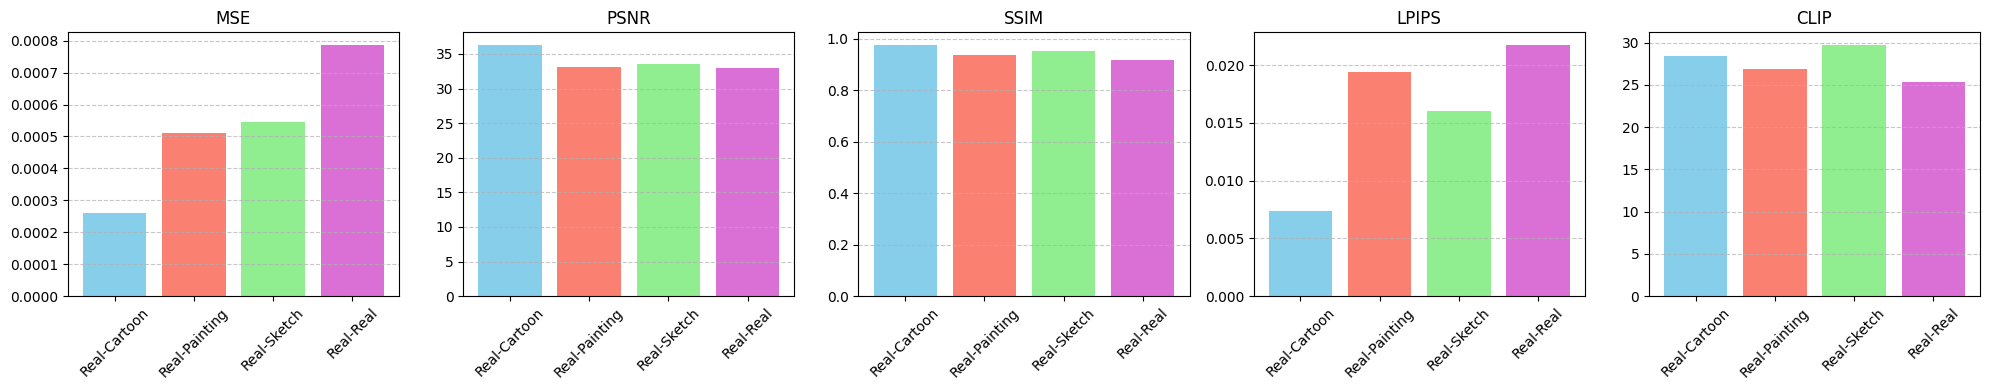

Saved plot data to EEdit_outputs/metrics/composition_plot_data.json


In [25]:
import matplotlib.pyplot as plt
import json
import os

# Extract groups and metrics from the comp_results dictionary
groups = list(comp_results.keys())
metrics = ['mse', 'psnr', 'ssim', 'lpips', 'clip']

# Prepare data for plotting
plot_data = {m: [] for m in metrics}
for g in groups:
    for m in metrics:
        plot_data[m].append(comp_results[g]['average'][m])

# Plotting
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 4))
colors = ['skyblue', 'salmon', 'lightgreen', 'orchid']

for i, m in enumerate(metrics):
    axes[i].bar(groups, plot_data[m], color=colors[:len(groups)])
    axes[i].set_title(m.upper())
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Save as JSON
out_json = "EEdit_outputs/metrics/composition_plot_data.json"
os.makedirs(os.path.dirname(out_json), exist_ok=True)
with open(out_json, "w") as f:
    json.dump({"groups": groups, "data": plot_data}, f, indent=2)
print(f"Saved plot data to {out_json}")

In [26]:
%cd /content/EEdit
import json
from pathlib import Path

drag_root = Path('/content/EEdit/input/drag_data')
entries = []
for img_file in sorted(drag_root.rglob('original_image.png')):
    d = img_file.parent
    rel = './' + str(d.relative_to('/content/EEdit')).replace('\\', '/')
    entries.append({'data_path': rel})

out = '/content/EEdit/configs/drag/dragging_images.json'
with open(out, 'w') as f:
    json.dump({'imgs': entries}, f, indent=2)

print(f'dragging_images.json: {len(entries)} samples -> {out}')

/content/EEdit
dragging_images.json: 305 samples -> /content/EEdit/configs/drag/dragging_images.json


### Smoke Test — Drag (2 samples)

Runs drag editing on **2 samples** before the full run.

In [28]:
%cd /content/EEdit
import json, os
from pathlib import Path

# --- Patch for region_utils/drag.py ---
drag_script_path = "./region_utils/drag.py"
if os.path.exists(drag_script_path):
    with open(drag_script_path, "r") as f:
        content = f.read()
    # Replace the hardcoded expected filename to match the dataset
    content = content.replace("meta_data_region.pkl", "meta_data.pkl")
    with open(drag_script_path, "w") as f:
        f.write(content)
    print("Patched region_utils/drag.py to use meta_data.pkl")
# --------------------------------------

with open("configs/drag/dragging_images.json") as f:
    full = json.load(f)
assert len(full["imgs"]) > 0, "dragging_images.json is empty — run drag-config-build cell first"

test_cfg = {"imgs": full["imgs"][:2]}
with open("configs/drag/test_dragging.json", "w") as f:
    json.dump(test_cfg, f)
print(f'Smoke-test config: {len(test_cfg["imgs"])} drag samples')

os.makedirs("EEdit_outputs/test_drag", exist_ok=True)
!python drag_gen.py \
  --weights_dir ./weights \
  --config_path ./configs/drag/cache_configs.json \
  --img_config  ./configs/drag/test_dragging.json \
  --output_dir  ./EEdit_outputs/test_drag \
  --use_predefine 1

n = len(list(Path("EEdit_outputs/test_drag").glob("*.png")))
print(f"\nSmoke-test result: {n}/2 images generated.")
if n == 0:
    raise RuntimeError("Drag smoke test FAILED — 0 images produced. Fix the error above before running the full pipeline.")
elif n < 2:
    print(f"WARNING: only {n}/2 images produced — check for errors above.")
else:
    print("Smoke test PASSED. Ready for full drag run.")


/content/EEdit
Patched region_utils/drag.py to use meta_data.pkl
Smoke-test config: 2 drag samples
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.44it/s]
Loading pipeline components...:  60% 3/5 [00:00<00:00,  6.04it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:00<00:00,  6.00it/s]
100% 28/28 [00:02<00:00, 13.74it/s]
100% 28/28 [00:02<00:00, 13.72it/s]

Smoke-test result: 2/2 images generated.
Smoke test PASSED. Ready for full drag run.


In [33]:
%cd /content/EEdit
import gc, torch
gc.collect(); torch.cuda.empty_cache()

os.makedirs('EEdit_outputs/drag', exist_ok=True)

!python drag_gen.py \
  --weights_dir ./weights \
  --config_path ./configs/drag/cache_configs.json \
  --img_config  ./configs/drag/dragging_images.json \
  --output_dir  ./EEdit_outputs/drag \
  --use_predefine 1

n = len(list(Path('EEdit_outputs/drag').glob('*.png')))
print(f'Drag done: {n} images saved.')

/content/EEdit
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.42it/s]
Loading pipeline components...:   0% 0/5 [00:00<?, ?it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:00<00:00,  5.97it/s]
100% 28/28 [00:02<00:00, 13.71it/s]
100% 28/28 [00:02<00:00, 13.68it/s]
100% 28/28 [00:02<00:00, 13.72it/s]
100% 28/28 [00:02<00:00, 13.69it/s]
100% 28/28 [00:02<00:00, 13.63it/s]
100% 28/28 [00:02<00:00, 13.61it/s]
100% 28/28 [00:02<00:00, 13.59it/s]
100% 28/28 [00:02<00:00, 13.68it/s]
100% 28/28 [00:02<00:00, 13.62it/s]
100% 28/28 [00:02<00:00, 13.62it/s]
100% 28/28 [00:02<00:00, 13.58it/s]
100% 28/28 [00:02<00:00, 13.60it/s]
100% 28/28 [00:01<00:00, 14.71it/s]
100% 28/28 [00:01<00:00, 14.79it/s]
100% 28/28 [00:02<00:00, 10.66it/s]
100% 28/28 [00:02<00:00, 11.73it/s]
100% 28/28 [00:01<00:00, 14.44it/s]
100% 28/28 [00:02<00:00, 10.66it/s]
100% 28/28 [00:02<00:00, 10.66i

In [34]:
%cd /content/EEdit
from pathlib import Path

gen_dir = Path("EEdit_outputs/drag")
gen_files = list(gen_dir.glob("*.png"))

print(f"Drag: {len(gen_files)} generated images")
print("Uploading ONLY generated drag results to Drive...")
upload_task_results("drag", str(gen_dir))

/content/EEdit
Drag: 328 generated images
Uploading ONLY generated drag results to Drive...


  generated/: 328 files
[drag] uploaded 328 files total.


'1hGbeiDhd2egRT-zeo942Y_mwQMK3SRvx'

### Drag Metrics (background preservation + CLIP)

Loads `meta_data.pkl` per sample to get source/target drag points and prompt.
Draws a circular mask around drag points; computes MSE/PSNR/SSIM/LPIPS on the non-drag region and CLIP score where a prompt is available.

In [35]:
%cd /content/EEdit
import os, json, sys, pickle
import numpy as np
import torch
import cv2
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
from tqdm import tqdm
from torchmetrics.multimodal.clip_score import CLIPScore

sys.path.insert(0, "/content/EEdit/img_metrics")
from calculate_ssim import calculate_ssim
from calculate_psnr import calculate_psnr
from calculate_lpips import calculate_lpips
from calculate_mse  import calculate_mse

SIZE = 512
clip_metric = CLIPScore(model_name_or_path="openai/clip-vit-large-patch14").to("cuda").eval()

def load_t(path):
    return T.ToTensor()(Image.open(path).convert("RGB").resize((SIZE, SIZE)))

def load_meta(data_path):
    for name in ["meta_data.pkl", "meta_data_region.pkl"]:
        p = os.path.join(data_path, name)
        if os.path.exists(p):
            with open(p, "rb") as f:
                return pickle.load(f)
    return None

def make_drag_mask(src_pts, tgt_pts, orig_w, orig_h, radius_frac=0.06):
    mask = np.zeros((orig_h, orig_w), dtype=np.float32)
    r    = max(10, int(min(orig_w, orig_h) * radius_frac))
    for pt in list(src_pts) + list(tgt_pts):
        cv2.circle(mask, (int(pt[0]), int(pt[1])), r, 1.0, -1)
    resized = cv2.resize(mask, (SIZE, SIZE), interpolation=cv2.INTER_NEAREST)
    return torch.from_numpy(resized).unsqueeze(0).float()

with open("configs/drag/dragging_images.json") as f:
    cfg = json.load(f)

gen_dir   = Path("EEdit_outputs/drag")
gen_files = sorted(gen_dir.glob("*.png"))
drag_results = []

for i, gf in enumerate(tqdm(gen_files, desc="Drag metrics")):
    if i >= len(cfg["imgs"]): break
    data_path = cfg["imgs"][i]["data_path"].lstrip("./")
    orig_path = os.path.join(data_path, "original_image.png")
    if not os.path.exists(orig_path): continue

    orig_pil = Image.open(orig_path).convert("RGB")
    orig_w, orig_h = orig_pil.size
    orig   = T.ToTensor()(orig_pil.resize((SIZE, SIZE)))
    edited = load_t(str(gf))

    meta   = load_meta(data_path)
    prompt = None
    bg_mask = torch.ones(1, SIZE, SIZE)  # default: full image

    if meta is not None:
        src = meta.get("handle_points", meta.get("source", meta.get("src_pts", [])))
        tgt = meta.get("target_points", meta.get("target", meta.get("tgt_pts", [])))
        prompt = meta.get("prompt", meta.get("text", None))
        if len(src) > 0 and len(tgt) > 0:
            drag_mask = make_drag_mask(src, tgt, orig_w, orig_h)
            bg_mask   = (drag_mask < 0.5).float()

    orig_bg = orig * bg_mask
    edit_bg = edited * bg_mask

    row = {
        "file": gf.name, "data_path": data_path,
        "mse":   calculate_mse(orig_bg, edit_bg)["value"],
        "psnr":  calculate_psnr(orig_bg, edit_bg)["value"],
        "ssim":  calculate_ssim(orig_bg, edit_bg)["value"],
        "lpips": calculate_lpips(orig_bg, edit_bg, "cuda")["value"][0],
    }
    if prompt:
        row["prompt"] = prompt
        img_t = T.PILToTensor()(Image.open(str(gf)).convert("RGB").resize((SIZE, SIZE)))
        with torch.no_grad():
            row["clip"] = clip_metric(img_t.unsqueeze(0).to("cuda"), [prompt]).item()
    drag_results.append(row)

drag_avg = {}
if drag_results:
    all_keys = [k for k in ("mse","psnr","ssim","lpips","clip")
                if all(k in r for r in drag_results)]
    n = len(drag_results)
    drag_avg = {k: sum(r[k] for r in drag_results)/n for k in all_keys}
    print(f"\nDrag ({n}): " +
          "  ".join(f'{k.upper()}={drag_avg[k]:.4f}' for k in all_keys))

os.makedirs("EEdit_outputs/metrics", exist_ok=True)
with open("EEdit_outputs/metrics/drag_metrics.json", "w") as f:
    json.dump({"individual": drag_results, "average": drag_avg}, f, indent=2)
print("Saved drag_metrics.json")


/content/EEdit


Drag metrics:  74%|███████▍  | 244/328 [01:04<00:22,  3.79it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (108 > 77). Running this sequence through the model will result in indexing errors
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered caption longer than max_position_embeddings=77. Will truncate captions to thislength. If longer captions are needed, initialize argument `model_name_or_path` with a model thatsupports longer sequences.
  warnings.warn(*args, **kwargs)
Drag metrics:  93%|█████████▎| 305/328 [01:20<00:06,  3.79it/s]


Drag (305): MSE=0.1540  PSNR=9.3348  SSIM=0.3012  LPIPS=0.7815  CLIP=11.0156
Saved drag_metrics.json


## 6. Evaluation Metrics

Computes the metrics from Table 1 of the EEdit paper:
- **Background preservation** (on the unedited region): MSE, PSNR, SSIM, LPIPS
- **Edit accuracy**: CLIP textâ€“image score

Reference values (EEdit with cache, PIE-Bench): MSEâ‰ˆ0.0057, PSNRâ‰ˆ24.87, SSIMâ‰ˆ0.8583, LPIPSâ‰ˆ0.0925, CLIPâ‰ˆ27.0

In [36]:
%pip install -q lpips torchmetrics
print('Metric deps ready.')

Metric deps ready.


In [37]:
import os, json, sys
import numpy as np
import torch
from PIL import Image
from pathlib import Path
import torchvision.transforms as T
from tqdm import tqdm

sys.path.insert(0, '/content/EEdit/img_metrics')
from calculate_ssim import calculate_ssim
from calculate_psnr import calculate_psnr
from calculate_lpips import calculate_lpips
from calculate_mse import calculate_mse

def load_t(path, size=512):
    return T.ToTensor()(Image.open(path).convert('RGB').resize((size, size)))

def load_mask_t(path, size=512):
    return T.ToTensor()(Image.open(path).convert('L').resize((size, size)))

with open('/content/EEdit/configs/prompt-guided/prompt_images.json') as f:
    config = json.load(f)

output_files = sorted(Path('/content/EEdit/EEdit_outputs/inpaint').glob('*.png'))
pairs = list(zip(output_files, config['imgs']))
print(f'Evaluating {len(pairs)} inpaint pairs...')

results = []
for out_file, cfg_item in tqdm(pairs):
    orig_abs = '/content/EEdit/' + cfg_item['image'].lstrip('./')
    mask_abs = '/content/EEdit/' + cfg_item['mask_image'].lstrip('./')
    if not (os.path.exists(orig_abs) and os.path.exists(mask_abs)):
        continue
    orig   = load_t(orig_abs)
    edited = load_t(str(out_file))
    mask   = load_mask_t(mask_abs)          # 1 = edited region
    bg     = (mask < 0.5).float()           # 1 = background
    orig_bg, edited_bg = orig * bg, edited * bg
    results.append({
        'file':  out_file.name,
        'prompt': cfg_item['prompt'],
        'mse':   calculate_mse(orig_bg, edited_bg)['value'],
        'psnr':  calculate_psnr(orig_bg, edited_bg)['value'],
        'ssim':  calculate_ssim(orig_bg, edited_bg)['value'],
        'lpips': calculate_lpips(orig_bg, edited_bg, 'cuda')['value'][0],
    })

n = len(results)
if n == 0:
    raise RuntimeError("No inpaint output images found. Re-run the inpaint-run cell first.")
bg_avg = {k: sum(r[k] for r in results) / n for k in ('mse', 'psnr', 'ssim', 'lpips')}

os.makedirs('/content/EEdit/EEdit_outputs/metrics', exist_ok=True)
with open('/content/EEdit/EEdit_outputs/metrics/inpaint_bg.json', 'w') as f:
    json.dump({'individual': results, 'average': bg_avg}, f, indent=2)

print(f'\nBackground Preservation ({n} images):')
print(f'  MSE:   {bg_avg["mse"]:.4f}   (paper â‰ˆ 0.0057)')
print(f'  PSNR:  {bg_avg["psnr"]:.2f} dB (paper â‰ˆ 24.87)')
print(f'  SSIM:  {bg_avg["ssim"]:.4f}   (paper â‰ˆ 0.8583)')
print(f'  LPIPS: {bg_avg["lpips"]:.4f}   (paper â‰ˆ 0.0925)')

Evaluating 700 inpaint pairs...


100%|██████████| 700/700 [01:49<00:00,  6.42it/s]


Background Preservation (700 images):
  MSE:   0.0040   (paper â‰ˆ 0.0057)
  PSNR:  40.41 dB (paper â‰ˆ 24.87)
  SSIM:  0.8326   (paper â‰ˆ 0.8583)
  LPIPS: 0.1099   (paper â‰ˆ 0.0925)


In [38]:
import torch
from torchmetrics.multimodal.clip_score import CLIPScore
from PIL import Image
import torchvision.transforms as T
from pathlib import Path
from tqdm import tqdm
import json

device = 'cuda'
clip_metric = CLIPScore(model_name_or_path='openai/clip-vit-large-patch14').to(device)
clip_metric.eval()

with open('/content/EEdit/configs/prompt-guided/prompt_images.json') as f:
    config = json.load(f)

output_files = sorted(Path('/content/EEdit/EEdit_outputs/inpaint').glob('*.png'))

clip_scores, clip_results = [], []
for out_file, cfg_item in tqdm(zip(output_files, config['imgs']), total=len(output_files)):
    try:
        img = T.PILToTensor()(Image.open(str(out_file)).convert('RGB').resize((512, 512)))
        with torch.no_grad():
            score = clip_metric(img.unsqueeze(0).to(device), [cfg_item['prompt']]).item()
        clip_scores.append(score)
        clip_results.append({'file': out_file.name, 'prompt': cfg_item['prompt'], 'clip': score})
    except Exception as e:
        print(f'  Error {out_file.name}: {e}')

avg_clip = sum(clip_scores) / len(clip_scores) if clip_scores else 0

with open('/content/EEdit/EEdit_outputs/metrics/inpaint_clip.json', 'w') as f:
    json.dump({'individual': clip_results, 'average_clip': avg_clip}, f, indent=2)

print(f'\nCLIP Text-Image Score ({len(clip_scores)} images): {avg_clip:.4f}  (paper â‰ˆ 27.0)')

100%|██████████| 700/700 [01:00<00:00, 11.53it/s]


CLIP Text-Image Score (700 images): 25.8298  (paper â‰ˆ 27.0)


In [39]:
import json, os

def _load(p):
    return json.load(open(p)) if os.path.exists(p) else {}

ib   = _load("EEdit_outputs/metrics/inpaint_bg.json").get("average", {})
ic   = _load("EEdit_outputs/metrics/inpaint_clip.json").get("average_clip")
ca   = _load("EEdit_outputs/metrics/composition_metrics.json").get("overall_average", {})
cg   = _load("EEdit_outputs/metrics/composition_metrics.json").get("per_group", {})
da   = _load("EEdit_outputs/metrics/drag_metrics.json").get("average", {})

W = 66
print("\n" + "="*W)
print("  EEdit Full Evaluation Results")
print("="*W)
print(f'  {"Metric":<30} {"This Run":>10}  {"Paper ref":>14}')

# ── Inpaint ──
print("\n  ── Prompt-Guided Editing  (PIE-Bench) ──")
rows = [
    ("mse",   "MSE  (background)",     "≈ 0.0057",  f'{ib.get("mse", float("nan")):.4f}'),
    ("psnr",  "PSNR (background) dB",  "≈ 24.87",   f'{ib.get("psnr",float("nan")):.2f}'),
    ("ssim",  "SSIM (background)",     "≈ 0.8583",  f'{ib.get("ssim",float("nan")):.4f}'),
    ("lpips", "LPIPS (background)",    "≈ 0.0925",  f'{ib.get("lpips",float("nan")):.4f}'),
    ("clip",  "CLIP Score",            "≈ 27.0",    f'{ic:.4f}' if ic else "N/A"),
]
for _, label, ref, val in rows:
    print(f'  {label:<30} {val:>10}  {ref:>14}')

# ── Composition ──
if ca:
    print("\n  ── Reference-Guided Composition  (TF-ICON) ──")
    for key, label in [("mse","MSE (background)"),("psnr","PSNR (background) dB"),
                        ("ssim","SSIM (background)"),("lpips","LPIPS (background)"),
                        ("clip","CLIP Score")]:
        if key in ca:
            v = f'{ca[key]:.2f}' if key in ("psnr","clip") else f'{ca[key]:.4f}'
            print(f'  {label:<30} {v:>10}  {"(no paper ref)":>14}')
    for group, gdata in cg.items():
        avg = gdata.get("average", {})
        n   = gdata.get("count", 0)
        clip_g = f'{avg["clip"]:.2f}' if "clip" in avg else "N/A"
        ssim_g = f'{avg["ssim"]:.4f}' if "ssim" in avg else "N/A"
        print(f'    {group} (n={n}): SSIM={ssim_g}  CLIP={clip_g}')

# ── Drag ──
if da:
    print("\n  ── Drag Editing  (DragBench-DR + DragBench-SR) ──")
    for key, label in [("mse","MSE (non-drag region)"),("psnr","PSNR (non-drag) dB"),
                        ("ssim","SSIM (non-drag)"),("lpips","LPIPS (non-drag)"),
                        ("clip","CLIP Score")]:
        if key in da:
            v = f'{da[key]:.2f}' if key in ("psnr","clip") else f'{da[key]:.4f}'
            print(f'  {label:<30} {v:>10}  {"(no paper ref)":>14}')

print("\n" + "="*W)
print("Reference: EEdit arxiv:2503.10270")
print("Note: Official eval code not yet released — composition & drag ref values unavailable.")



  EEdit Full Evaluation Results
  Metric                           This Run       Paper ref

  ── Prompt-Guided Editing  (PIE-Bench) ──
  MSE  (background)                  0.0040        ≈ 0.0057
  PSNR (background) dB                40.41         ≈ 24.87
  SSIM (background)                  0.8326        ≈ 0.8583
  LPIPS (background)                 0.1099        ≈ 0.0925
  CLIP Score                        25.8298          ≈ 27.0

  ── Reference-Guided Composition  (TF-ICON) ──
  MSE (background)                   0.0007  (no paper ref)
  PSNR (background) dB                33.28  (no paper ref)
  SSIM (background)                  0.9270  (no paper ref)
  LPIPS (background)                 0.0198  (no paper ref)
  CLIP Score                          26.18  (no paper ref)
    Real-Cartoon (n=27): SSIM=0.9767  CLIP=28.42
    Real-Painting (n=37): SSIM=0.9368  CLIP=26.90
    Real-Sketch (n=31): SSIM=0.9531  CLIP=29.72
    Real-Real (n=237): SSIM=0.9164  CLIP=25.35

  ── Drag Editing  

## 7. Upload All Results to Google Drive

Uploads the entire `EEdit_outputs/` folder into your output Drive folder.

View at: https://drive.google.com/drive/folders/1R0DNBTzobpIOyYDZuy5YZ2lc599nTu8Q

In [40]:
# Upload evaluation metrics JSON files
metrics_dir = "/content/EEdit/EEdit_outputs/metrics"
if os.path.isdir(metrics_dir):
    metrics_id = _gdrive_mkdir(drive_service, "metrics", _get_run_folder())
    n = _upload_tree(drive_service, metrics_dir, metrics_id)
    print(f"Metrics uploaded: {n} files")
else:
    print("No metrics folder found (run the metrics cells first).")

print(f"\nAll done! View all results:")
print(f"https://drive.google.com/drive/folders/1R0DNBTzobpIOyYDZuy5YZ2lc599nTu8Q")


Metrics uploaded: 5 files

All done! View all results:
https://drive.google.com/drive/folders/1R0DNBTzobpIOyYDZuy5YZ2lc599nTu8Q


## 8. Upload to GitHub

Uploads all project files and generated outputs to the `EEdit_baseline` branch of your GitHub repository, excluding the heavy `weights` directory.

In [ ]:
import os
from getpass import getpass

print("Please enter your GitHub Personal Access Token (PAT):")
print("Note: The token must have 'repo' scope permissions.")
github_token = getpass("GitHub Token: ")

github_user = "AimeeAyat"
repo_name = "FIA-EDIT-DVLM"
branch_name = "EEdit_baseline"
repo_url = f"https://{github_token}@github.com/{github_user}/{repo_name}.git"

# Remove previous clone if we're re-running
!rm -rf /content/{repo_name}

# Clone the target repo
print(f"\nCloning {github_user}/{repo_name}...")
!git clone {repo_url} /content/{repo_name}

%cd /content/{repo_name}

# Configure git user
!git config user.email "colab-bot@example.com"
!git config user.name "Colab Bot"

# Checkout the target branch (create if it doesn't exist)
!git fetch origin
!git checkout {branch_name} || git checkout -b {branch_name}

# Copy EEdit files to the repo, explicitly excluding the weights directory and the EEdit .git tracking
print("\nCopying files (this may take a moment)...")
!rsync -av --exclude='weights' --exclude='.git' /content/EEdit/ /content/{repo_name}/

# Add, commit, and push
print("\nCommitting and pushing to GitHub...")
!git add .
!git commit -m "Upload EEdit project files and generated outputs (excluding weights)" || echo "No changes to commit"
!git push -u origin {branch_name}

print(f"\nSuccessfully pushed to https://github.com/{github_user}/{repo_name}/tree/{branch_name}")
%cd /content/EEdit


Streaming output truncated to the last 5000 lines.
input/composition/Real-Cartoon/Re_0020 0020 a cartoon animation of a castle in the distance/
input/composition/Real-Cartoon/Re_0020 0020 a cartoon animation of a castle in the distance/bg59.png
input/composition/Real-Cartoon/Re_0020 0020 a cartoon animation of a castle in the distance/fg24_63d22ad01f5b66e8e5ac3988_skyscraper.jpg
input/composition/Real-Cartoon/Re_0020 0020 a cartoon animation of a castle in the distance/fg24_mask.png
input/composition/Real-Cartoon/Re_0020 0020 a cartoon animation of a castle in the distance/mask_bg_fg.jpg
input/composition/Real-Cartoon/Re_0021 0021 a cartoon animation of buildings in the distance/
input/composition/Real-Cartoon/Re_0021 0021 a cartoon animation of buildings in the distance/bg59.png
input/composition/Real-Cartoon/Re_0021 0021 a cartoon animation of buildings in the distance/fg65_63d22bbb1f5b66e8e5ac6aee.jpg
input/composition/Real-Cartoon/Re_0021 0021 a cartoon animation of buildings in th